Entregable Urgente - Análisis de Riesgo y Cuellos de Botella en Proveedores

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [3]:
df = pd.read_csv("data.csv")
print(df)

    Order_ID Buyer_ID Supplier_ID Product_Category  Quantity_Ordered  \
0      O1000      B33         S23         Textiles               469   
1      O1001       B1         S20        Machinery               365   
2      O1002       B2         S10             Food               333   
3      O1003       B6         S10        Machinery               142   
4      O1004       B5          S4        Machinery               897   
..       ...      ...         ...              ...               ...   
995    O1995      B23         S27           Pharma                31   
996    O1996      B45          S2      Electronics               419   
997    O1997      B22         S24      Electronics               904   
998    O1998      B10         S26         Textiles               524   
999    O1999       B4          S9             Food               136   

     Order_Date Dispatch_Date Delivery_Date Shipping_Mode  Order_Value_USD  \
0    2023-10-24    2023-10-27    2023-10-28          Rail

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Order_ID                      1000 non-null   object 
 1   Buyer_ID                      1000 non-null   object 
 2   Supplier_ID                   1000 non-null   object 
 3   Product_Category              1000 non-null   object 
 4   Quantity_Ordered              1000 non-null   int64  
 5   Order_Date                    1000 non-null   object 
 6   Dispatch_Date                 1000 non-null   object 
 7   Delivery_Date                 1000 non-null   object 
 8   Shipping_Mode                 1000 non-null   object 
 9   Order_Value_USD               1000 non-null   float64
 10  Delay_Days                    1000 non-null   int64  
 11  Disruption_Type               514 non-null    object 
 12  Disruption_Severity           514 non-null    object 
 13  Hist

In [7]:
df.head()

,Order_ID,Buyer_ID,Supplier_ID,Product_Category,Quantity_Ordered,Order_Date,Dispatch_Date,Delivery_Date,Shipping_Mode,Order_Value_USD,...,Supplier_Reliability_Score,Organization_ID,Dominant_Buyer_Flag,Available_Historical_Records,Data_Sharing_Consent,Federated_Round,Parameter_Change_Magnitude,Communication_Cost_MB,Energy_Consumption_Joules,Supply_Risk_Flag
0,O1000,B33,S23,Textiles,469,2023-10-24,2023-10-27,2023-10-28,Rail,36273.99,...,0.73,Org13,0,127,1,10,0.0225,2.27,236.06,0
1,O1001,B1,S20,Machinery,365,2023-07-07,2023-07-08,2023-07-09,Road,34780.36,...,0.88,Org8,1,909,1,7,0.0412,3.10,257.80,0
2,O1002,B2,S10,Food,333,2023-12-28,2023-12-29,2024-01-07,Rail,7154.54,...,0.95,Org4,0,262,1,8,0.1183,2.82,165.38,1
3,O1003,B6,S10,Machinery,142,2023-01-14,2023-01-17,2023-01-20,Rail,15320.08,...,0.92,Org18,1,807,1,9,0.2611,3.59,377.47,0
4,O1004,B5,S4,Machinery,897,2023-01-12,2023-01-14,2023-01-16,Road,18256.42,...,0.60,Org13,0,789,1,7,0.2775,3.42,83.10,0


1. DATA CLEANING 

In [9]:
df.isna().sum()
#we found 486 missing values. But the value absence of this value means that the product was delivered perfectly

Order_ID                          0
Buyer_ID                          0
Supplier_ID                       0
Product_Category                  0
Quantity_Ordered                  0
Order_Date                        0
Dispatch_Date                     0
Delivery_Date                     0
Shipping_Mode                     0
Order_Value_USD                   0
Delay_Days                        0
Disruption_Type                 486
Disruption_Severity             486
Historical_Disruption_Count       0
Supplier_Reliability_Score        0
Organization_ID                   0
Dominant_Buyer_Flag               0
Available_Historical_Records      0
Data_Sharing_Consent              0
Federated_Round                   0
Parameter_Change_Magnitude        0
Communication_Cost_MB             0
Energy_Consumption_Joules         0
Supply_Risk_Flag                  0
dtype: int64

In [13]:
#fill missing values
df["Disruption_Type"] = df["Disruption_Type"].fillna("Sin retrasos")
df["Disruption_Severity"] = df["Disruption_Severity"].fillna("Ninguna")
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 24 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Order_ID                      1000 non-null   object 
 1   Buyer_ID                      1000 non-null   object 
 2   Supplier_ID                   1000 non-null   object 
 3   Product_Category              1000 non-null   object 
 4   Quantity_Ordered              1000 non-null   int64  
 5   Order_Date                    1000 non-null   object 
 6   Dispatch_Date                 1000 non-null   object 
 7   Delivery_Date                 1000 non-null   object 
 8   Shipping_Mode                 1000 non-null   object 
 9   Order_Value_USD               1000 non-null   float64
 10  Delay_Days                    1000 non-null   int64  
 11  Disruption_Type               1000 non-null   object 
 12  Disruption_Severity           1000 non-null   object 
 13  Hist

2. What are the 3 suppliers that ae causing the most trouble by acummulating delay days

In [18]:
Top_3_major_delays = df.groupby("Supplier_ID")["Delay_Days"].sum().sort_values(ascending= False).head(3)
Top_3_major_delays

#As we can see this three supliers need especial attention because between them there are more than 300 days of delays combined

Supplier_ID
S24    120
S4     118
S23     97
Name: Delay_Days, dtype: int64

3. FINANCIAL VALUE AT RISK

In [ ]:
#filter all records with delays
df_delays = df[df["Delay_Days"]> 0]
df_delays

,Order_ID,Buyer_ID,Supplier_ID,Product_Category,Quantity_Ordered,Order_Date,Dispatch_Date,Delivery_Date,Shipping_Mode,Order_Value_USD,...,Supplier_Reliability_Score,Organization_ID,Dominant_Buyer_Flag,Available_Historical_Records,Data_Sharing_Consent,Federated_Round,Parameter_Change_Magnitude,Communication_Cost_MB,Energy_Consumption_Joules,Supply_Risk_Flag
2,O1002,B2,S10,Food,333,2023-12-28,2023-12-29,2024-01-07,Rail,7154.54,...,0.95,Org4,0,262,1,8,0.1183,2.82,165.38,1
9,O1009,B26,S13,Machinery,613,2023-08-31,2023-09-01,2023-09-10,Sea,938.73,...,0.53,Org17,0,879,1,6,0.0827,3.14,305.37,1
13,O1013,B49,S8,Pharma,60,2023-08-26,2023-08-28,2023-09-05,Sea,15083.66,...,0.72,Org17,0,829,0,4,0.4937,0.84,208.79,1
14,O1014,B3,S5,Textiles,38,2023-12-22,2023-12-23,2024-01-01,Air,1208.61,...,0.51,Org13,1,89,1,9,0.4420,4.61,114.38,1
16,O1016,B7,S27,Textiles,305,2023-08-09,2023-08-10,2023-08-13,Sea,41790.16,...,0.93,Org17,0,31,1,2,0.3464,4.83,96.81,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
987,O1987,B23,S22,Textiles,392,2023-07-03,2023-07-04,2023-07-12,Air,48682.44,...,0.91,Org11,0,855,0,3,0.1930,1.31,74.46,1
989,O1989,B6,S10,Pharma,468,2023-03-25,2023-03-26,2023-04-03,Road,42445.70,...,0.72,Org5,0,611,1,6,0.4596,1.74,255.17,1
994,O1994,B30,S7,Machinery,323,2023-07-15,2023-07-18,2023-08-03,Rail,40940.21,...,0.56,Org4,0,284,0,8,0.1860,2.81,461.21,1
995,O1995,B23,S27,Pharma,31,2023-06-27,2023-07-01,2023-07-10,Sea,42701.10,...,0.93,Org9,0,518,1,10,0.3041,3.70,147.10,1


In [28]:
financial_value_risk = df_delays.groupby("Product_Category")["Order_Value_USD"].sum().sort_values(ascending=False).reset_index()
financial_value_risk

,Product_Category,Order_Value_USD
0,Electronics,2950797.82
1,Textiles,2849067.99
2,Food,2592732.53
3,Pharma,2328502.08
4,Machinery,2238039.12


4. VISUAL REPRESENTATION

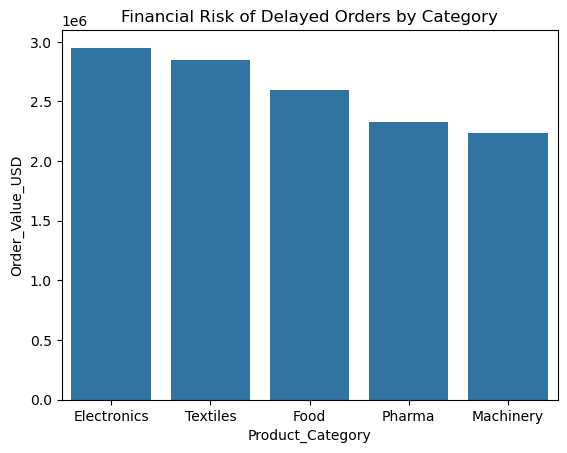

In [29]:
# Create the bar chart
sns.barplot(data=financial_value_risk, x="Product_Category", y="Order_Value_USD")

#Add a professional title for the committee
plt.title("Financial Risk of Delayed Orders by Category")

plt.show();